# 03_Serverless_Application_in_AWS


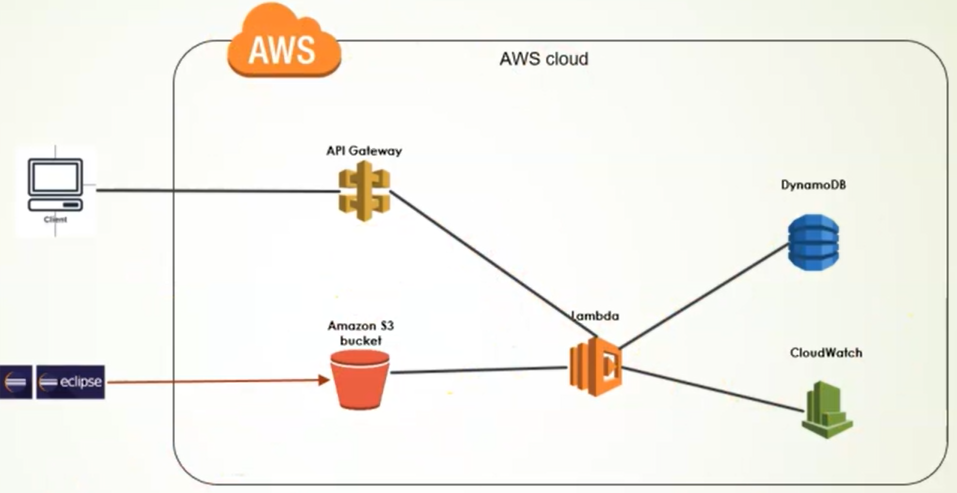


* **Client** → **API Gateway** → **Lambda** → **DynamoDB & CloudWatch**
* **Developer Tools (Eclipse)** → **S3 Bucket** → **Lambda Deployment**

We’ll explain **each component**, **how requests flow**, **how code is deployed**, and give **alternative scenarios and examples**.

---

## 1. High‑Level Architecture

Inside the AWS cloud box you can see:

* **API Gateway** – front door for HTTP/REST requests.
* **Amazon S3 bucket** – storage for code artifacts or static assets.
* **AWS Lambda** – compute layer running your functions.
* **DynamoDB** – NoSQL database for application data.
* **CloudWatch** – logging, metrics, and monitoring.

Outside the cloud box:

* A **client** (web browser / mobile app / Postman) that calls the API.
* A **developer IDE (Eclipse)** that uploads code to S3.

This is a classic **AWS serverless pattern**: the only compute you manage is Lambda functions, and they scale automatically.

---

## 2. Roles of Each AWS Service

### 2.1 API Gateway

**Purpose:**

* Acts as a managed **HTTP/REST API front end**.
* Receives requests from clients, performs validation/auth, and forwards them to **Lambda** or other backends.

**Key features:**

* **Routing:** Map `GET /items`, `POST /items`, etc., to specific Lambda functions.
* **Security:** Integrate with IAM, Cognito user pools, or custom authorizers.
* **Request/Response transformation:** Convert JSON formats, add headers, etc.
* **Rate limiting and throttling:** Protect backends from being overloaded.

**Benefit in serverless context:**

* You don’t run Nginx or an Express server—API Gateway handles all HTTP boilerplate.

### 2.2 AWS Lambda

**Purpose:**

* Run small pieces of code **on demand**.
* Auto‑scales and you **pay per invocation and execution time**.

**Supported runtimes (examples):** Node.js, Python, Java, .NET, Go, Ruby, and custom runtimes via container images.

**In this diagram:**

* Lambda is the **central box**. It:

  * Receives events from API Gateway.
  * Reads/writes data from/to DynamoDB.
  * Logs to CloudWatch.

### 2.3 Amazon S3 Bucket

In a typical serverless app, S3 can have two roles:

1. **Deployment artifact storage**

   * Developer packages code (ZIP/JAR) and uploads to S3 (from Eclipse or CI/CD).
   * Lambda function configuration references this object as its code source.

2. **Application data storage**

   * Static web site assets (HTML, CSS, JS) hosted from S3.
   * User files: images, PDFs, etc.

In the slide, S3 is mainly shown as the **bucket that holds your Lambda deployment package** uploaded from Eclipse.

### 2.4 DynamoDB

**Purpose:**

* Fully managed, highly scalable **NoSQL key‑value and document database**.
* Serverless by nature—no instances to manage.

**Why it fits serverless:**

* Capacity scales automatically (on‑demand mode).
* Pricing is per read/write request unit.

Typical uses in this architecture:

* Store user profiles, orders, session data, API payloads, etc.
* Lambda reads from and writes to DynamoDB via AWS SDK.

### 2.5 CloudWatch

**Purpose:**

* Central **logging, metrics, and alarms** service.

In a serverless architecture:

* Every Lambda invocation can write logs (`console.log`, `System.out.println`, etc.) → **CloudWatch Logs**.
* CloudWatch also collects:

  * Number of invocations.
  * Duration.
  * Errors and throttles.
* You can create **alarms** (e.g., if error rate > 5% for 5 minutes, send alert to SNS/email).

CloudWatch is crucial because you **don’t have servers** where you can SSH and read log files—everything goes into CloudWatch.

---

## 3. Request Flow: From Client to Database

Let’s walk step‑by‑step through a typical request, e.g., `POST /items` from a web app.

1. **Client Sends HTTP Request**

   * A browser running a JavaScript SPA or a mobile app sends an HTTPS request to `https://api.example.com/items`.

2. **API Gateway Receives the Request**

   * API Gateway verifies the request:

     * Checks **authentication** (e.g., JWT from Cognito) and **authorization** (IAM policies).
     * Optionally validates the payload against a **JSON schema**.
   * If invalid → responds with `4xx` error directly.

3. **API Gateway Triggers Lambda**

   * For a valid request, API Gateway creates a JSON event and calls the configured **Lambda function**.
   * The event usually contains:

     * HTTP method, path, headers.
     * Query params and path params.
     * Request body.
     * Authorizer context (e.g., user ID).

4. **Lambda Function Executes Business Logic**

   * Runtime environment is created (or reused if warm):

     * Lambda loads your code.
     * Runs handler function, e.g., `handler(event, context)`.
   * Code may:

     * Validate / transform input.
     * Interact with other AWS services (DynamoDB, S3, SQS, SNS, etc.).

5. **Lambda Reads/Writes DynamoDB**

   * Using AWS SDK, e.g. `PutItem`, `GetItem`, `Query`.
   * Example: new item record with attributes `id`, `userId`, `createdAt`, `data`.

6. **Lambda Writes Logs to CloudWatch**

   * Every log statement is captured and streamed to **CloudWatch Logs**.
   * You can later search by request id or error messages.

7. **Lambda Returns Response to API Gateway**

   * Lambda returns statusCode + headers + body.

8. **API Gateway Returns HTTP Response to Client**

   * API Gateway forwards the result as an HTTP response.
   * Client receives JSON payload and updates UI.

This entire workflow is **stateless** and **event‑driven**. No server is always running just for this endpoint.

---

## 4. Code Deployment Flow: From Eclipse to Lambda

The slide shows **Eclipse → S3 bucket → Lambda**. Here’s how that works in more detail.

### 4.1 Packaging the Lambda Function

1. Developer writes code in **Eclipse** (for example, a Java handler class implementing `RequestHandler`).
2. They build the project into a **JAR** or **ZIP** archive:

   * Includes compiled classes and dependencies.

### 4.2 Uploading to S3

3. The build process or an IDE plugin uploads this artifact to an **S3 bucket**.

   * Example key: `lambda-artifacts/my-function-1.0.0.jar`.

### 4.3 Creating/Updating the Lambda Function

4. In AWS Lambda configuration, you specify:

   * Code location: S3 bucket + object key.
   * Runtime: e.g., Java 17, memory size, timeout.
   * Handler name: `com.example.MyHandler::handleRequest`.
   * IAM role (what the function can access: DynamoDB tables, CloudWatch, etc.).

5. When you deploy a new version:

   * Lambda downloads the artifact from S3.
   * Creates a new version of the function.

### 4.4 Optional: CI/CD

Instead of Eclipse directly uploading to S3, in a professional setup you might:

* Push code to **GitHub/GitLab**.
* CI/CD pipeline (CodeBuild, GitHub Actions) builds and uploads artifact to S3.
* **CloudFormation / CDK / SAM** updates the Lambda function and API Gateway configuration.

---

## 5. Example Use Case: TODO List API

To make this concrete, imagine a serverless **TODO List** backend using this architecture.

### 5.1 Data Model in DynamoDB

Table: `TodoTable`

* Partition key: `userId` (string).
* Sort key: `todoId` (string).
* Attributes: `title`, `completed` (boolean), `createdAt`, `updatedAt`.

### 5.2 Lambda Functions

1. `CreateTodoFunction`

   * Trigger: `POST /todos` via API Gateway.
   * Steps:

     * Parse `title` from JSON body.
     * Generate `todoId` and timestamps.
     * Put item into DynamoDB.
     * Return created record.

2. `ListTodosFunction`

   * Trigger: `GET /todos`.
   * Steps:

     * Query DynamoDB for items with the user’s `userId`.
     * Return list.

3. `UpdateTodoFunction`

   * Trigger: `PUT /todos/{id}`.
   * Steps:

     * Read existing item.
     * Apply updates (set `completed = true`).
     * Write back with conditional update.

4. `DeleteTodoFunction`

   * Trigger: `DELETE /todos/{id}`.
   * Steps:

     * Delete item from DynamoDB.

All functions log activity (userId, todoId, errors) to CloudWatch.

### 5.3 Advantages of This Serverless Setup

* **Scaling:** If 10 users or 1 million users send requests, AWS automatically scales Lambda and DynamoDB.
* **Cost:** No cost when no one uses the app. You pay per function execution + DynamoDB read/write and some API Gateway cost.
* **Operations:** No servers to patch, upgrade, or scale manually.

---

## 6. Another Example: Image Processing Pipeline

Using the same pattern, we can build an image processing workflow.

1. Frontend directly uploads an image to **S3**.
2. S3 **event** triggers a Lambda function.
3. Lambda:

   * Reads the image from S3.
   * Generates thumbnails.
   * Saves them to another S3 bucket.
   * Stores metadata (paths, resolutions) in **DynamoDB**.
4. Logs success/failure to **CloudWatch**.

In this variant, API Gateway might not even be needed for the processing part; S3 events are enough.

---

## 7. Security and Permissions

Serverless apps rely heavily on **IAM roles and policies**.

### 7.1 Lambda Execution Role

* Each Lambda function has an **execution role** granting it permissions.
* For this architecture, the role might allow:

  * `dynamodb:PutItem`, `dynamodb:Query` on specific tables.
  * `logs:CreateLogGroup`, `logs:CreateLogStream`, `logs:PutLogEvents` for CloudWatch.

### 7.2 API Gateway Authorization

Common patterns:

* **Cognito User Pools** for user sign‑up/sign‑in.
* **JWT tokens** on requests; API Gateway verifies them.
* Custom Lambda authorizer to implement special auth logic.

### 7.3 Least Privilege

Important exam/real‑world point:

* Grant only the permissions each function needs.
* Separate roles for different Lambdas (e.g., read‑only vs write).

---

## 8. Observability and Troubleshooting

Because there are no servers to log into, tools like **CloudWatch** and **X‑Ray** are essential.

### 8.1 CloudWatch Logs

* Every Lambda invocation has a **request id**.
* You can filter by `ERROR` or that request id to trace a single failing request.

### 8.2 Metrics

Key metrics to monitor:

* Invocations and errors.
* Duration (average, p95, p99).
* Throttles (when concurrency limits are exceeded).

### 8.3 Alerts

Set up alarms such as:

* Error rate > 2% for last 5 minutes → send SNS notification.
* Throttles > 0 for last 15 minutes → page on‑call engineer.

---

## 9. Strengths and Limitations of This Serverless Pattern

### 9.1 Strengths

* **No server management:** You never administer EC2 instances.
* **Pay‑per‑use:** Ideal for bursty workloads and prototypes.
* **Rapid development:** Focus only on business logic; integration with AWS services is straightforward via SDK.
* **High scalability:** Lambda and DynamoDB handle huge traffic with minimal config.

### 9.2 Limitations

* **Cold start latency:** Especially for Java or large functions.
* **Execution time limit:** Lambda functions have a max duration (e.g., 15 minutes).
* **Complexity at scale:** Many small functions and APIs mean more moving parts (permissions, versioning, routing).
* **Vendor lock‑in:** Architecture heavily depends on AWS services and their event models.

---

## 10. Summary Mental Picture

From the diagram and this deep dive, remember this mental model of an AWS serverless app:

1. **Client** talks to **API Gateway** over HTTPS.
2. API Gateway turns the HTTP request into an **event** and triggers **Lambda**.
3. Lambda runs your code only when needed, using **S3** for code storage and **DynamoDB** for data.
4. All logs and metrics go to **CloudWatch**.
5. You pay only for what you use, and AWS handles scaling and infrastructure.

This is the essence of a **serverless application in AWS**, and variations on this pattern appear in many real‑world systems and exam questions.
